# 💰 AI-Based Financial Advisor
### ML Project | 2nd Year College | Python + Sklearn

---

**Project Overview:**
Yeh project ek AI-powered financial advisor hai jo aapki income, expenses, savings aur goals ke basis par:
- Risk level predict karega (Low / Medium / High)
- Budget recommendation dega
- Investment suggestions dega (FD, Mutual Funds, Stocks)
- Simple financial advice dega

---

## 📦 STEP 1: Libraries Import Karo

Sabse pehle saari zaruri libraries import karte hain. Yeh libraries hame data handle karne, graphs banane aur ML model train karne mein help karengi.

In [1]:
# === STEP 1: IMPORT ALL REQUIRED LIBRARIES ===
# Yahan pe saari libraries import kar rahe hain

import pandas as pd                          # Data manipulation ke liye
import numpy as np                           # Numerical operations ke liye
import matplotlib.pyplot as plt              # Graphs banane ke liye
import matplotlib.patches as mpatches       # Graph legends ke liye
from matplotlib.gridspec import GridSpec    # Subplots layout ke liye
import warnings
warnings.filterwarnings('ignore')            # Warnings hide karo

# Sklearn se ML tools
from sklearn.model_selection import train_test_split   # Data split karne ke liye
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Data preprocess karne ke liye
from sklearn.ensemble import RandomForestClassifier    # Main ML model
from sklearn.linear_model import LogisticRegression   # Alternate ML model
from sklearn.metrics import (
    accuracy_score,           # Model accuracy check karne ke liye
    classification_report,    # Detailed report ke liye
    confusion_matrix          # Confusion matrix ke liye
)

# Style set karo graphs ke liye
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Saari libraries successfully import ho gayi!")
print("📊 Ab hum dataset banana shuru karte hain...")

✅ Saari libraries successfully import ho gayi!
📊 Ab hum dataset banana shuru karte hain...


## 🗃️ STEP 2: Synthetic Dataset Banao

Hum ek synthetic (artificial) dataset banayenge jo real-world financial data jaise lagega.

**Dataset mein yeh columns honge:**
| Column | Description |
|--------|-------------|
| `income` | Maahana income (₹) |
| `expenses` | Maahana expenses (₹) |
| `savings` | Maahana savings (₹) |
| `debt` | Total debt amount (₹) |
| `financial_goal` | Goal: retirement/house/education/emergency |
| `risk_preference` | Low/Medium/High |
| `savings_rate` | Savings as % of income |
| `expense_ratio` | Expenses as % of income |
| `debt_to_income` | Debt to income ratio |
| `risk_label` | Target variable: 0=Low, 1=Medium, 2=High |

In [2]:
# === STEP 2: SYNTHETIC DATASET BANANA ===
# Real data nahi hai toh hum khud data banayenge jo real jaisa lage

np.random.seed(42)   # Seed set karo taaki har baar same results aayein
n_samples = 10000     # 1000 log ka data banayenge

# --- Income generate karo (₹20,000 to ₹2,00,000 per month) ---
income = np.random.randint(20000, 200000, n_samples)

# --- Expenses generate karo (income ka 30% to 85%) ---
expense_ratio = np.random.uniform(0.30, 0.85, n_samples)
expenses = (income * expense_ratio).astype(int)

# --- Savings calculate karo ---
savings = income - expenses
savings = np.maximum(savings, 0)   # Negative savings nahi hona chahiye

# --- Debt generate karo (0 to income ka 5 guna) ---
debt = np.random.randint(0, income * 5, n_samples)

# --- Financial Goals ---
goals = np.random.choice(
    ['retirement', 'house', 'education', 'emergency'],
    n_samples
)

# --- Risk Preference ---
risk_pref = np.random.choice(['low', 'medium', 'high'], n_samples)

# --- Derived features banao ---
savings_rate = savings / income          # Savings ka % of income
debt_to_income = debt / (income + 1)     # Debt to income ratio

# --- Risk Label assign karo (Rule-based logic se) ---
# Yeh label hai jo hum predict karna chahte hain
risk_label = []
for i in range(n_samples):
    sr = savings_rate[i]        # Savings rate
    dti = debt_to_income[i]     # Debt to income ratio
    er = expense_ratio[i]       # Expense ratio
    rp = risk_pref[i]           # User ki risk preference
    
    # Rule: Agar savings kam hai ya debt zyada hai → High Risk
    if sr < 0.10 or dti > 3.0 or er > 0.75:
        label = 2  # High Risk
    # Rule: Agar savings theek hai aur debt manageable hai → Low Risk
    elif sr > 0.25 and dti < 1.0 and er < 0.55:
        label = 0  # Low Risk
    else:
        label = 1  # Medium Risk
    
    # Risk preference ka thoda effect bhi daalo
    if rp == 'high' and label < 2:
        label = min(label + 1, 2)
    elif rp == 'low' and label > 0:
        label = max(label - 1, 0)
    
    risk_label.append(label)

# --- DataFrame banao ---
df = pd.DataFrame({
    'income': income,
    'expenses': expenses,
    'savings': savings,
    'debt': debt,
    'financial_goal': goals,
    'risk_preference': risk_pref,
    'savings_rate': savings_rate,
    'expense_ratio': expense_ratio,
    'debt_to_income': debt_to_income,
    'risk_label': risk_label
})

# Risk labels ko readable names mein convert karo
risk_map = {0: 'Low', 1: 'Medium', 2: 'High'}
df['risk_category'] = df['risk_label'].map(risk_map)

print(f"✅ Dataset successfully banaya gaya!")
print(f"📐 Dataset ka size: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📊 Risk Category Distribution:")
print(df['risk_category'].value_counts())
print(f"\n🔍 Dataset ki pehli 5 rows:")
df.head()

✅ Dataset successfully banaya gaya!
📐 Dataset ka size: 10000 rows × 11 columns

📊 Risk Category Distribution:
risk_category
High      4760
Medium    3292
Low       1948
Name: count, dtype: int64

🔍 Dataset ki pehli 5 rows:


,income,expenses,savings,debt,financial_goal,risk_preference,savings_rate,expense_ratio,debt_to_income,risk_label,risk_category
0,141958,109217,32741,301269,house,high,0.230639,0.769368,2.122225,2,High
1,166867,133975,32892,479757,education,low,0.197115,0.802887,2.875069,1,Medium
2,151932,67747,84185,476966,emergency,low,0.554097,0.445907,3.139318,1,Medium
3,123694,98605,25089,191157,emergency,low,0.202831,0.797174,1.545390,1,Medium
4,139879,66633,73246,318687,education,medium,0.523638,0.476365,2.278289,1,Medium


## 📊 STEP 3: Exploratory Data Analysis (EDA) - Data Ko Samjho

Data ko visualize karte hain taaki samajh aaye ki distribution kaisi hai.

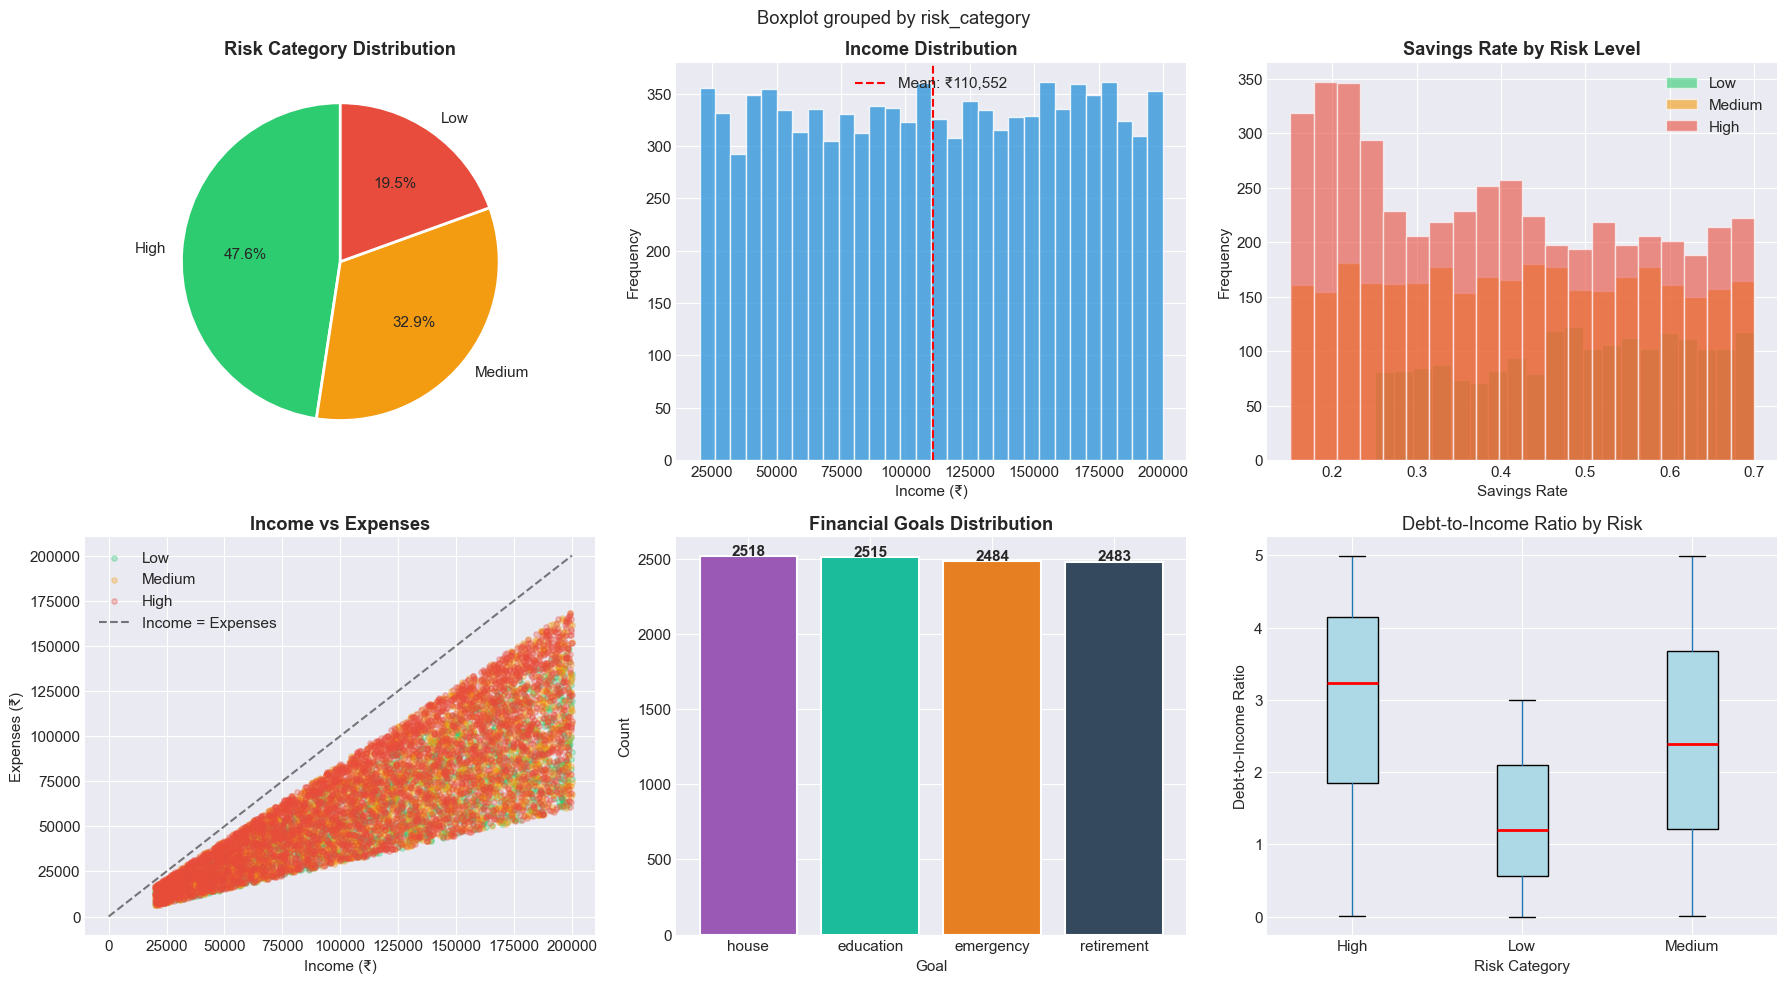

✅ EDA Graphs successfully display ho gaye!


In [3]:
# === STEP 3: DATA VISUALIZATION - EDA ===
# Dataset ke baare mein graphs se samjhenge

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Financial Dataset - Exploratory Data Analysis', 
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red

# --- Graph 1: Risk Category Distribution ---
risk_counts = df['risk_category'].value_counts()
axes[0, 0].pie(risk_counts.values, 
               labels=risk_counts.index, 
               autopct='%1.1f%%',
               colors=colors,
               startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Risk Category Distribution', fontweight='bold')

# --- Graph 2: Income Distribution ---
axes[0, 1].hist(df['income'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Income Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Income (₹)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['income'].mean(), color='red', linestyle='--', 
                    label=f'Mean: ₹{df["income"].mean():,.0f}')
axes[0, 1].legend()

# --- Graph 3: Savings Rate by Risk Category ---
for i, (risk, color) in enumerate(zip(['Low', 'Medium', 'High'], colors)):
    data = df[df['risk_category'] == risk]['savings_rate']
    axes[0, 2].hist(data, bins=20, alpha=0.6, color=color, label=risk, edgecolor='white')
axes[0, 2].set_title('Savings Rate by Risk Level', fontweight='bold')
axes[0, 2].set_xlabel('Savings Rate')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()

# --- Graph 4: Income vs Expenses Scatter ---
risk_colors_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
for risk, color in risk_colors_map.items():
    subset = df[df['risk_category'] == risk]
    axes[1, 0].scatter(subset['income'], subset['expenses'], 
                        alpha=0.3, color=color, label=risk, s=15)
axes[1, 0].plot([0, 200000], [0, 200000], 'k--', alpha=0.5, label='Income = Expenses')
axes[1, 0].set_title('Income vs Expenses', fontweight='bold')
axes[1, 0].set_xlabel('Income (₹)')
axes[1, 0].set_ylabel('Expenses (₹)')
axes[1, 0].legend()

# --- Graph 5: Financial Goals Distribution ---
goal_counts = df['financial_goal'].value_counts()
bars = axes[1, 1].bar(goal_counts.index, goal_counts.values, 
                       color=['#9b59b6', '#1abc9c', '#e67e22', '#34495e'],
                       edgecolor='white', linewidth=1.5)
axes[1, 1].set_title('Financial Goals Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Goal')
axes[1, 1].set_ylabel('Count')
for bar, val in zip(bars, goal_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(val), ha='center', fontweight='bold')

# --- Graph 6: Debt-to-Income by Risk ---
df.boxplot(column='debt_to_income', by='risk_category', ax=axes[1, 2],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1, 2].set_title('Debt-to-Income Ratio by Risk', fontweight='bold')
axes[1, 2].set_xlabel('Risk Category')
axes[1, 2].set_ylabel('Debt-to-Income Ratio')
plt.sca(axes[1, 2])
plt.title('Debt-to-Income Ratio by Risk')

plt.tight_layout()
plt.savefig('eda_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Graphs successfully display ho gaye!")

## ⚙️ STEP 4: Data Preprocessing

ML model ko train karne se pehle data ko prepare karna padta hai:
- **Label Encoding**: Text features ko numbers mein convert karo
- **Feature Scaling**: Saari values ko same scale par laao
- **Train-Test Split**: Data ko training aur testing mein baanto

In [4]:
# === STEP 4: DATA PREPROCESSING ===
# ML model ke liye data ko ready karo

print("🔧 Data Preprocessing shuru...")
print("=" * 50)

# --- Step 4a: Label Encoding ---
# Text columns ko numbers mein convert karo
le_goal = LabelEncoder()       # Financial goal encoder
le_risk = LabelEncoder()       # Risk preference encoder

df['goal_encoded'] = le_goal.fit_transform(df['financial_goal'])
df['riskpref_encoded'] = le_risk.fit_transform(df['risk_preference'])

print("✅ Label Encoding done:")
print(f"   Financial Goal mapping: {dict(zip(le_goal.classes_, le_goal.transform(le_goal.classes_)))}")
print(f"   Risk Pref mapping: {dict(zip(le_risk.classes_, le_risk.transform(le_risk.classes_)))}")

# --- Step 4b: Features aur Target select karo ---
# X = input features, y = target (predict karna hai)
feature_columns = [
    'income', 'expenses', 'savings', 'debt',
    'savings_rate', 'expense_ratio', 'debt_to_income',
    'goal_encoded', 'riskpref_encoded'
]

X = df[feature_columns]    # Input features
y = df['risk_label']       # Target variable (0=Low, 1=Medium, 2=High)

print(f"\n✅ Features selected: {len(feature_columns)} features")
print(f"   Features: {feature_columns}")
print(f"   Target: risk_label (0=Low, 1=Medium, 2=High)")

# --- Step 4c: Train-Test Split ---
# 80% training ke liye, 20% testing ke liye
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test data
    random_state=42,    # Reproducibility ke liye
    stratify=y          # Har class equally distribute ho
)

print(f"\n✅ Train-Test Split done:")
print(f"   Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

# --- Step 4d: Feature Scaling ---
# StandardScaler: mean=0, std=1 kardo saari features ko
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Train pe fit karo
X_test_scaled = scaler.transform(X_test)          # Test pe sirf transform karo

print(f"\n✅ Feature Scaling done (StandardScaler)")
print(f"   Mean of first feature before scaling: {X_train.iloc[:, 0].mean():.2f}")
print(f"   Mean of first feature after scaling: {X_train_scaled[:, 0].mean():.4f}")
print("\n🎉 Preprocessing complete! Ab model train karte hain...")

🔧 Data Preprocessing shuru...
✅ Label Encoding done:
   Financial Goal mapping: {'education': 0, 'emergency': 1, 'house': 2, 'retirement': 3}
   Risk Pref mapping: {'high': 0, 'low': 1, 'medium': 2}

✅ Features selected: 9 features
   Features: ['income', 'expenses', 'savings', 'debt', 'savings_rate', 'expense_ratio', 'debt_to_income', 'goal_encoded', 'riskpref_encoded']
   Target: risk_label (0=Low, 1=Medium, 2=High)

✅ Train-Test Split done:
   Training samples: 8000 (80%)
   Testing samples: 2000 (20%)

✅ Feature Scaling done (StandardScaler)
   Mean of first feature before scaling: 110506.71
   Mean of first feature after scaling: 0.0000

🎉 Preprocessing complete! Ab model train karte hain...


## 🤖 STEP 5: ML Models Train Karo

Hum 2 models train karenge aur compare karenge:
1. **Logistic Regression** - Simple, fast, linear model
2. **Random Forest** - Powerful ensemble model (main model)

In [5]:
# === STEP 5: MODEL TRAINING ===
# Do alag models train karenge aur compare karenge

print("🤖 Model Training shuru...")
print("=" * 50)

# --- Model 1: Logistic Regression ---
print("\n📌 Model 1: Logistic Regression training ho raha hai...")
lr_model = LogisticRegression(
    max_iter=1000,     # Maximum iterations
    random_state=42,
    multi_class='ovr'  # One vs Rest strategy
)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"   ✅ Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

# --- Model 2: Random Forest (Main Model) ---
print("\n📌 Model 2: Random Forest training ho raha hai...")
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,        # Tree ki maximum depth
    random_state=42,
    n_jobs=-1            # All CPU cores use karo
)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"   ✅ Random Forest Accuracy: {rf_accuracy*100:.2f}%")

# --- Model Comparison ---
print("\n" + "=" * 50)
print("📊 MODEL COMPARISON:")
print("=" * 50)
print(f"  Logistic Regression : {lr_accuracy*100:.2f}%")
print(f"  Random Forest       : {rf_accuracy*100:.2f}%")
print("=" * 50)

# Best model select karo
best_model = rf_model if rf_accuracy >= lr_accuracy else lr_model
best_model_name = "Random Forest" if rf_accuracy >= lr_accuracy else "Logistic Regression"
best_accuracy = max(rf_accuracy, lr_accuracy)
best_predictions = rf_predictions if rf_accuracy >= lr_accuracy else lr_predictions

print(f"\n🏆 Best Model: {best_model_name} ({best_accuracy*100:.2f}% accuracy)")
print("\n✅ Model Training Complete!")

🤖 Model Training shuru...

📌 Model 1: Logistic Regression training ho raha hai...
   ✅ Logistic Regression Accuracy: 55.25%

📌 Model 2: Random Forest training ho raha hai...
   ✅ Random Forest Accuracy: 100.00%

📊 MODEL COMPARISON:
  Logistic Regression : 55.25%
  Random Forest       : 100.00%

🏆 Best Model: Random Forest (100.00% accuracy)

✅ Model Training Complete!


## 📈 STEP 6: Model Evaluation - Performance Check Karo

📊 MODEL PERFORMANCE REPORT

🏆 Random Forest - Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       390
 Medium Risk       1.00      1.00      1.00       658
   High Risk       1.00      1.00      1.00       952

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



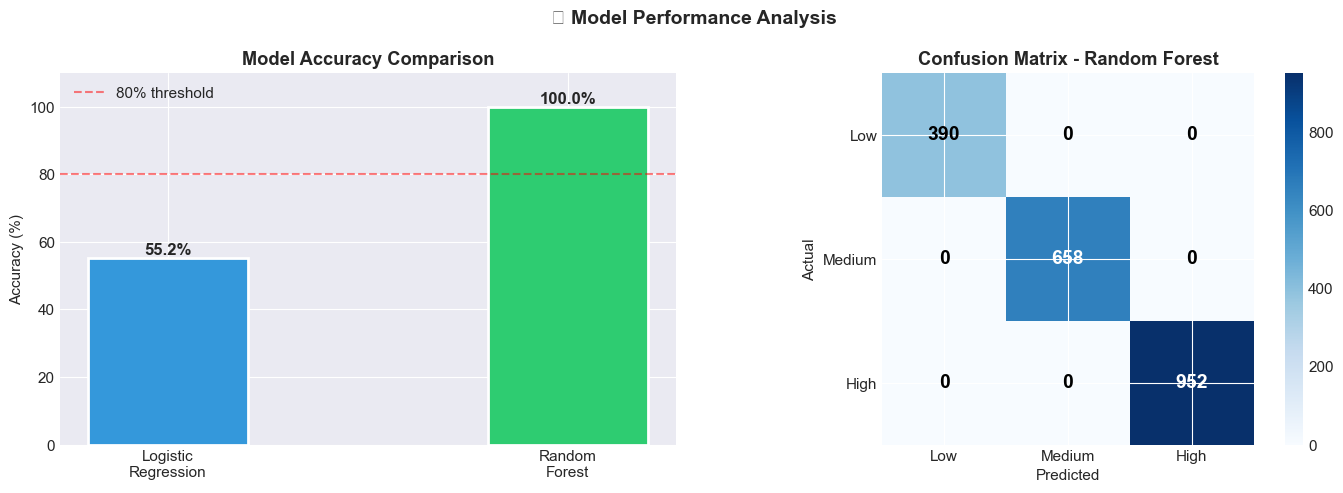


✅ Model Evaluation complete!


In [6]:
# === STEP 6: MODEL EVALUATION ===
# Model kitna acha hai yeh check karte hain

print("📊 MODEL PERFORMANCE REPORT")
print("=" * 60)

# Detailed Classification Report
print(f"\n🏆 {best_model_name} - Detailed Classification Report:")
print("-" * 60)
target_names = ['Low Risk', 'Medium Risk', 'High Risk']
print(classification_report(y_test, best_predictions, target_names=target_names))

# Visualization: Accuracy Comparison + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🤖 Model Performance Analysis', fontsize=14, fontweight='bold')

# --- Graph 1: Model Accuracy Comparison ---
models = ['Logistic\nRegression', 'Random\nForest']
accuracies = [lr_accuracy * 100, rf_accuracy * 100]
bar_colors = ['#3498db', '#2ecc71']
bars = axes[0].bar(models, accuracies, color=bar_colors, edgecolor='white', 
                    linewidth=2, width=0.4)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
axes[0].legend()

# --- Graph 2: Confusion Matrix ---
cm = confusion_matrix(y_test, best_predictions)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
tick_marks = np.arange(len(target_names))
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_yticklabels(['Low', 'Medium', 'High'])
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Numbers dikhao confusion matrix mein
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, format(cm[i, j], 'd'),
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model Evaluation complete!")

## 🌟 STEP 7: Feature Importance - Kaunsa Feature Sabse Important Hai?

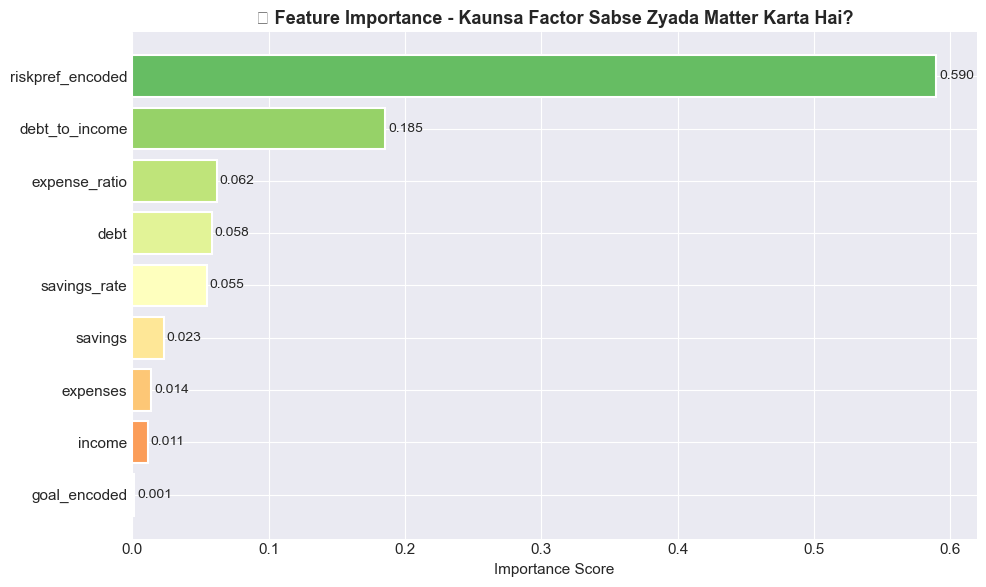


🔍 Top 3 Most Important Features:
   1. expense_ratio: 0.0619
   2. debt_to_income: 0.1855
   3. riskpref_encoded: 0.5898


In [7]:
# === STEP 7: FEATURE IMPORTANCE ===
# Random Forest batata hai ki kaunsa feature prediction mein sabse important hai

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], 
                feature_importance['Importance'],
                color=colors_fi, edgecolor='white', linewidth=1.5)

# Values dikhao
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('🔍 Feature Importance - Kaunsa Factor Sabse Zyada Matter Karta Hai?', 
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Top 3 Most Important Features:")
top3 = feature_importance.tail(3)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Importance']:.4f}")

## 📅 STEP 8: 30-Day Financial Trend Simulation

Yeh function user ke finances ka agle 30 din ka trend simulate karega aur graph banayega.

In [8]:
# === STEP 8: 30-DAY FINANCIAL TREND SIMULATION ===
# User ke finances ka 30 din ka projection dikhayenge

def simulate_30_day_trend(monthly_income, monthly_expenses, monthly_savings, risk_level):
    """
    30 din ka financial trend simulate karta hai.
    
    Parameters:
    - monthly_income: Monthly income in ₹
    - monthly_expenses: Monthly expenses in ₹  
    - monthly_savings: Monthly savings in ₹
    - risk_level: 'Low', 'Medium', ya 'High'
    
    Returns:
    - Figure with trend graphs
    """
    
    days = np.arange(1, 31)  # 1 se 30 din
    
    # Daily amounts calculate karo
    daily_income = monthly_income / 30
    daily_expenses = monthly_expenses / 30
    daily_savings = monthly_savings / 30
    
    # Thoda randomness add karo (real life mein fluctuations hote hain)
    np.random.seed(42)
    
    # Cumulative income (steady badh raha hai)
    income_trend = np.cumsum(
        daily_income + np.random.normal(0, daily_income * 0.05, 30)
    )
    
    # Cumulative expenses (irregular spending)
    expense_noise = np.random.exponential(daily_expenses * 0.3, 30)
    expense_trend = np.cumsum(
        daily_expenses + expense_noise - expense_noise.mean()
    )
    expense_trend = np.maximum(expense_trend, 0)
    
    # Cumulative savings
    savings_trend = income_trend - expense_trend
    
    # Savings goal line (target)
    savings_goal = np.linspace(0, monthly_savings * 1.2, 30)
    
    # --- Graphs banao ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    risk_color = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    color = risk_color.get(risk_level, '#3498db')
    
    fig.suptitle(f'📅 30-Day Financial Trend Simulation | Risk Level: {risk_level}',
                fontsize=13, fontweight='bold')
    
    # --- Graph 1: Income vs Expenses (30 days) ---
    axes[0].fill_between(days, income_trend, expense_trend, 
                          where=(income_trend >= expense_trend),
                          alpha=0.3, color='green', label='Positive Balance')
    axes[0].fill_between(days, income_trend, expense_trend,
                          where=(income_trend < expense_trend),
                          alpha=0.3, color='red', label='Deficit')
    axes[0].plot(days, income_trend, 'g-', linewidth=2.5, label='Income', marker='o', markersize=3)
    axes[0].plot(days, expense_trend, 'r-', linewidth=2.5, label='Expenses', marker='s', markersize=3)
    axes[0].set_title('💰 Cumulative Income vs Expenses', fontweight='bold')
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Amount (₹)')
    axes[0].legend()
    axes[0].set_xlim(1, 30)
    
    # Format y-axis
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}')
    )
    
    # --- Graph 2: Savings Trend ---
    axes[1].plot(days, savings_trend, color=color, linewidth=2.5, 
                  label='Actual Savings', zorder=5)
    axes[1].plot(days, savings_goal, 'k--', linewidth=1.5, 
                  label='Savings Goal', alpha=0.7)
    axes[1].fill_between(days, savings_trend, 0, alpha=0.2, color=color)
    
    # Mark end values
    axes[1].annotate(f'₹{savings_trend[-1]:,.0f}', 
                      xy=(30, savings_trend[-1]),
                      xytext=(25, savings_trend[-1] + monthly_savings * 0.1),
                      arrowprops=dict(arrowstyle='->', color='black'),
                      fontsize=10, fontweight='bold')
    
    axes[1].set_title('💎 30-Day Savings Trend', fontweight='bold')
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Savings (₹)')
    axes[1].legend()
    axes[1].set_xlim(1, 30)
    axes[1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}')
    )
    
    plt.tight_layout()
    plt.savefig('trend_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return income_trend[-1], expense_trend[-1], savings_trend[-1]

# Test karo sample data se
print("📅 30-Day Trend Simulation function ready hai!")
print("Isko hum prediction ke saath use karenge...")

📅 30-Day Trend Simulation function ready hai!
Isko hum prediction ke saath use karenge...


## 🎯 STEP 9: Main Prediction Function - `predict_user_finance()`

Yeh sabse important function hai! Yeh user ki details leta hai aur complete financial analysis deta hai.

In [9]:
# === STEP 9: MAIN PREDICTION FUNCTION ===
# Yeh function user ki input leta hai aur financial advice deta hai

def predict_user_finance(income, expenses, savings, debt, 
                          financial_goal, risk_preference, 
                          show_trend=True):
    """
    AI-Based Financial Advisor - Main Prediction Function
    
    Parameters:
    -----------
    income (int)          : Monthly income in ₹
    expenses (int)        : Monthly expenses in ₹
    savings (int)         : Monthly savings in ₹
    debt (int)            : Total debt in ₹
    financial_goal (str)  : 'retirement', 'house', 'education', 'emergency'
    risk_preference (str) : 'low', 'medium', 'high'
    show_trend (bool)     : 30-day trend graph dikhao ya nahi
    
    Returns:
    --------
    dict: prediction results
    """
    
    # ─── INPUT VALIDATION ───
    valid_goals = ['retirement', 'house', 'education', 'emergency']
    valid_risk = ['low', 'medium', 'high']
    
    financial_goal = financial_goal.lower().strip()
    risk_preference = risk_preference.lower().strip()
    
    if financial_goal not in valid_goals:
        print(f"⚠️  Invalid goal! Valid options: {valid_goals}")
        return None
    if risk_preference not in valid_risk:
        print(f"⚠️  Invalid risk preference! Valid options: {valid_risk}")
        return None
    
    # ─── DERIVED FEATURES CALCULATE KARO ───
    savings_rate = savings / (income + 1)
    expense_ratio = expenses / (income + 1)
    debt_to_income = debt / (income + 1)
    
    # ─── ENCODE TEXT FEATURES ───
    goal_enc = le_goal.transform([financial_goal])[0]
    risk_enc = le_risk.transform([risk_preference])[0]
    
    # ─── USER DATA ARRAY BANAO ───
    user_data = np.array([[
        income, expenses, savings, debt,
        savings_rate, expense_ratio, debt_to_income,
        goal_enc, risk_enc
    ]])
    
    # ─── SCALE KARO ───
    user_data_scaled = scaler.transform(user_data)
    
    # ─── PREDICTION KARO ───
    prediction = best_model.predict(user_data_scaled)[0]
    probabilities = best_model.predict_proba(user_data_scaled)[0]
    
    risk_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
    risk_emojis = {0: '🟢', 1: '🟡', 2: '🔴'}
    predicted_risk = risk_labels[prediction]
    confidence = probabilities[prediction] * 100
    
    # ─── CONFIDENCE LEVEL ───
    if confidence >= 75:
        conf_label = "High Confidence"
        conf_emoji = "💪"
    elif confidence >= 50:
        conf_label = "Medium Confidence"
        conf_emoji = "🤔"
    else:
        conf_label = "Low Confidence"
        conf_emoji = "❓"
    
    # ─── BUDGET RECOMMENDATION ───
    # 50-30-20 rule based recommendations
    ideal_expenses = income * 0.50
    ideal_savings = income * 0.20
    ideal_wants = income * 0.30
    
    budget_surplus = savings - ideal_savings
    expense_status = "Over Budget" if expenses > ideal_expenses else "Under Control"
    
    # ─── INVESTMENT RECOMMENDATION ───
    def get_investment_plan(risk_level, savings_available, goal):
        """
        Risk level aur goal ke basis par investment plan banata hai
        """
        plans = {
            'Low': {
                'primary': 'Fixed Deposits (FD)',
                'secondary': 'PPF (Public Provident Fund)',
                'tertiary': 'Liquid Mutual Funds',
                'avoid': 'Direct Stocks, Crypto',
                'allocation': {'FD': 40, 'PPF': 30, 'Liquid Funds': 20, 'Emergency Fund': 10},
                'expected_return': '6-8% per year'
            },
            'Medium': {
                'primary': 'Mutual Funds (SIP)',
                'secondary': 'Index Funds (Nifty 50)',
                'tertiary': 'Corporate Bonds + FD',
                'avoid': 'Crypto, High-risk penny stocks',
                'allocation': {'Mutual Funds': 35, 'Index Funds': 25, 'FD/Bonds': 25, 'Emergency Fund': 15},
                'expected_return': '10-14% per year'
            },
            'High': {
                'primary': 'Direct Stocks (Large Cap)',
                'secondary': 'Equity Mutual Funds',
                'tertiary': 'Small/Mid Cap Funds',
                'avoid': 'Excessive leverage, Penny stocks',
                'allocation': {'Direct Stocks': 40, 'Equity MF': 30, 'Small/Mid Cap': 20, 'Emergency': 10},
                'expected_return': '15-20% per year (volatile)'
            }
        }
        return plans[risk_level]
    
    investment_plan = get_investment_plan(predicted_risk, savings, financial_goal)
    
    # ─── FINANCIAL ADVICE ───
    advice_list = []
    
    if savings_rate < 0.10:
        advice_list.append("⚠️  Savings bahut kam hai! Apni expenses 10-15% reduce karo")
    elif savings_rate > 0.30:
        advice_list.append("✅ Excellent savings rate! Isse invest karna shuru karo")
    else:
        advice_list.append("👍 Savings rate theek hai, thoda aur improve karo")
    
    if debt_to_income > 3.0:
        advice_list.append("🚨 Debt bahut zyada hai! Pehle debt clear karo")
    elif debt_to_income > 1.0:
        advice_list.append("⚡ Debt manageable hai, systematically reduce karo")
    else:
        advice_list.append("✅ Debt level healthy hai, keep it up!")
    
    if expense_ratio > 0.75:
        advice_list.append("📊 Expenses income ka 75%+ hai - spending audit karo")
    
    # Goal-specific advice
    goal_advice = {
        'retirement': "🏖️  Retirement ke liye NPS ya PPF mein invest karo",
        'house': "🏠 Home loan ke liye CIBIL score maintain karo (750+)",
        'education': "🎓 Education ke liye SIP start karo, Sukanya Samriddhi consider karo",
        'emergency': "🛡️  3-6 months ki emergency fund banao pehle"
    }
    advice_list.append(goal_advice[financial_goal])
    
    # ─── PRINT BEAUTIFUL RESULTS ───
    
    print("\n" + "═" * 65)
    print("       🏦 AI FINANCIAL ADVISOR - COMPLETE ANALYSIS REPORT")
    print("═" * 65)
    
    print("\n📝 USER INPUT SUMMARY:")
    print(f"   Monthly Income   : ₹{income:,}")
    print(f"   Monthly Expenses : ₹{expenses:,}")
    print(f"   Monthly Savings  : ₹{savings:,}")
    print(f"   Total Debt       : ₹{debt:,}")
    print(f"   Financial Goal   : {financial_goal.capitalize()}")
    print(f"   Risk Preference  : {risk_preference.capitalize()}")
    
    print("\n" + "─" * 65)
    print("🎯 RISK PREDICTION RESULT:")
    print("─" * 65)
    print(f"   Risk Level       : {risk_emojis[prediction]} {predicted_risk} Risk")
    print(f"   Confidence       : {conf_emoji} {confidence:.1f}% ({conf_label})")
    print(f"   Model Used       : {best_model_name}")
    print(f"   Accuracy         : {best_accuracy*100:.2f}%")
    
    print("\n" + "─" * 65)
    print("📊 PROBABILITY BREAKDOWN:")
    print("─" * 65)
    for i, (label, prob) in enumerate(zip(['Low Risk', 'Medium Risk', 'High Risk'], probabilities)):
        bar = '█' * int(prob * 30)
        print(f"   {label:12s}: {bar} {prob*100:.1f}%")
    
    print("\n" + "─" * 65)
    print("💰 BUDGET ANALYSIS (50-30-20 Rule):")
    print("─" * 65)
    print(f"   Needs (50%)   : Ideal ₹{ideal_expenses:,.0f} | Actual ₹{expenses:,}")
    print(f"   Wants (30%)   : Ideal ₹{ideal_wants:,.0f} | Budget for fun")
    print(f"   Savings (20%) : Ideal ₹{ideal_savings:,.0f} | Actual ₹{savings:,}")
    print(f"   Status        : {expense_status}")
    if budget_surplus > 0:
        print(f"   Surplus       : ₹{budget_surplus:,.0f} extra savings - invest karo!")
    else:
        print(f"   Deficit       : ₹{abs(budget_surplus):,.0f} zyada savings ki zarurat")
    
    print("\n" + "─" * 65)
    print("📈 INVESTMENT RECOMMENDATIONS:")
    print("─" * 65)
    print(f"   Primary Option    : {investment_plan['primary']}")
    print(f"   Secondary Option  : {investment_plan['secondary']}")
    print(f"   Third Option      : {investment_plan['tertiary']}")
    print(f"   Avoid             : {investment_plan['avoid']}")
    print(f"   Expected Returns  : {investment_plan['expected_return']}")
    
    print("\n   📦 Suggested Allocation:")
    for instrument, percentage in investment_plan['allocation'].items():
        amount = savings * percentage / 100
        bar = '▓' * (percentage // 3)
        print(f"   {instrument:20s}: {bar} {percentage}% = ₹{amount:,.0f}/month")
    
    print("\n" + "─" * 65)
    print("💡 FINANCIAL ADVICE:")
    print("─" * 65)
    for i, advice in enumerate(advice_list, 1):
        print(f"   {i}. {advice}")
    
    print("\n" + "═" * 65)
    print("   ✅ Analysis Complete! | Remember: Invest wisely, Save more!")
    print("═" * 65)
    
    # ─── 30-DAY TREND ───
    if show_trend:
        print("\n📅 30-Day Financial Trend Simulation:")
        simulate_30_day_trend(income, expenses, savings, predicted_risk)
    
    # Result return karo
    return {
        'risk_level': predicted_risk,
        'confidence': confidence,
        'confidence_label': conf_label,
        'probabilities': dict(zip(['Low', 'Medium', 'High'], probabilities)),
        'investment_plan': investment_plan,
        'advice': advice_list
    }

print("✅ predict_user_finance() function ready hai!")
print("Ab STEP 10 mein is function ko use karenge.")

✅ predict_user_finance() function ready hai!
Ab STEP 10 mein is function ko use karenge.


## 🚀 STEP 10: User 1 - Working Professional ka Analysis

Ab hum actual predictions karenge. Pehle ek working professional ka example lete hain.

👤 EXAMPLE 1: Rahul - Software Engineer, 28 years old
-----------------------------------------------------------------

═════════════════════════════════════════════════════════════════
       🏦 AI FINANCIAL ADVISOR - COMPLETE ANALYSIS REPORT
═════════════════════════════════════════════════════════════════

📝 USER INPUT SUMMARY:
   Monthly Income   : ₹75,000
   Monthly Expenses : ₹45,000
   Monthly Savings  : ₹20,000
   Total Debt       : ₹500,000
   Financial Goal   : Retirement
   Risk Preference  : Medium

─────────────────────────────────────────────────────────────────
🎯 RISK PREDICTION RESULT:
─────────────────────────────────────────────────────────────────
   Risk Level       : 🔴 High Risk
   Confidence       : 💪 92.8% (High Confidence)
   Model Used       : Random Forest
   Accuracy         : 100.00%

─────────────────────────────────────────────────────────────────
📊 PROBABILITY BREAKDOWN:
─────────────────────────────────────────────────────────────────
   Low Risk    :  0.

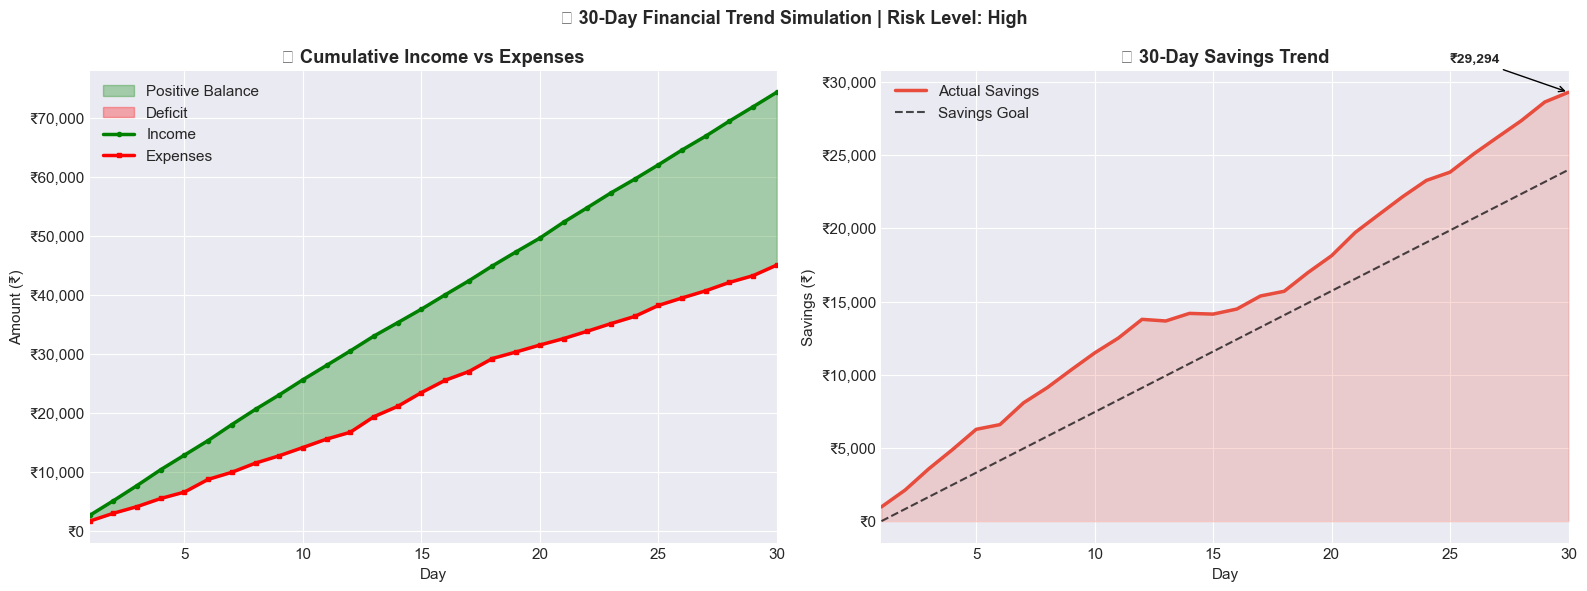

In [10]:
# === STEP 10: EXAMPLE 1 - WORKING PROFESSIONAL ===
# Ek typical working professional ki financial analysis

print("👤 EXAMPLE 1: Rahul - Software Engineer, 28 years old")
print("-" * 65)

result1 = predict_user_finance(
    income=75000,           # ₹75,000 per month salary
    expenses=45000,         # ₹45,000 monthly expenses
    savings=20000,          # ₹20,000 monthly savings
    debt=500000,            # ₹5 lakh ka loan (education/vehicle)
    financial_goal='retirement',  # Retirement ke liye plan kar raha hai
    risk_preference='medium',     # Medium risk lena chahta hai
    show_trend=True
)

## 🚀 STEP 11: User 2 - Young Student / Early Career

👤 EXAMPLE 2: Priya - Fresher, 23 years old
-----------------------------------------------------------------

═════════════════════════════════════════════════════════════════
       🏦 AI FINANCIAL ADVISOR - COMPLETE ANALYSIS REPORT
═════════════════════════════════════════════════════════════════

📝 USER INPUT SUMMARY:
   Monthly Income   : ₹30,000
   Monthly Expenses : ₹27,000
   Monthly Savings  : ₹2,000
   Total Debt       : ₹200,000
   Financial Goal   : Emergency
   Risk Preference  : Low

─────────────────────────────────────────────────────────────────
🎯 RISK PREDICTION RESULT:
─────────────────────────────────────────────────────────────────
   Risk Level       : 🟡 Medium Risk
   Confidence       : 💪 96.4% (High Confidence)
   Model Used       : Random Forest
   Accuracy         : 100.00%

─────────────────────────────────────────────────────────────────
📊 PROBABILITY BREAKDOWN:
─────────────────────────────────────────────────────────────────
   Low Risk    :  0.0%
   Medium 

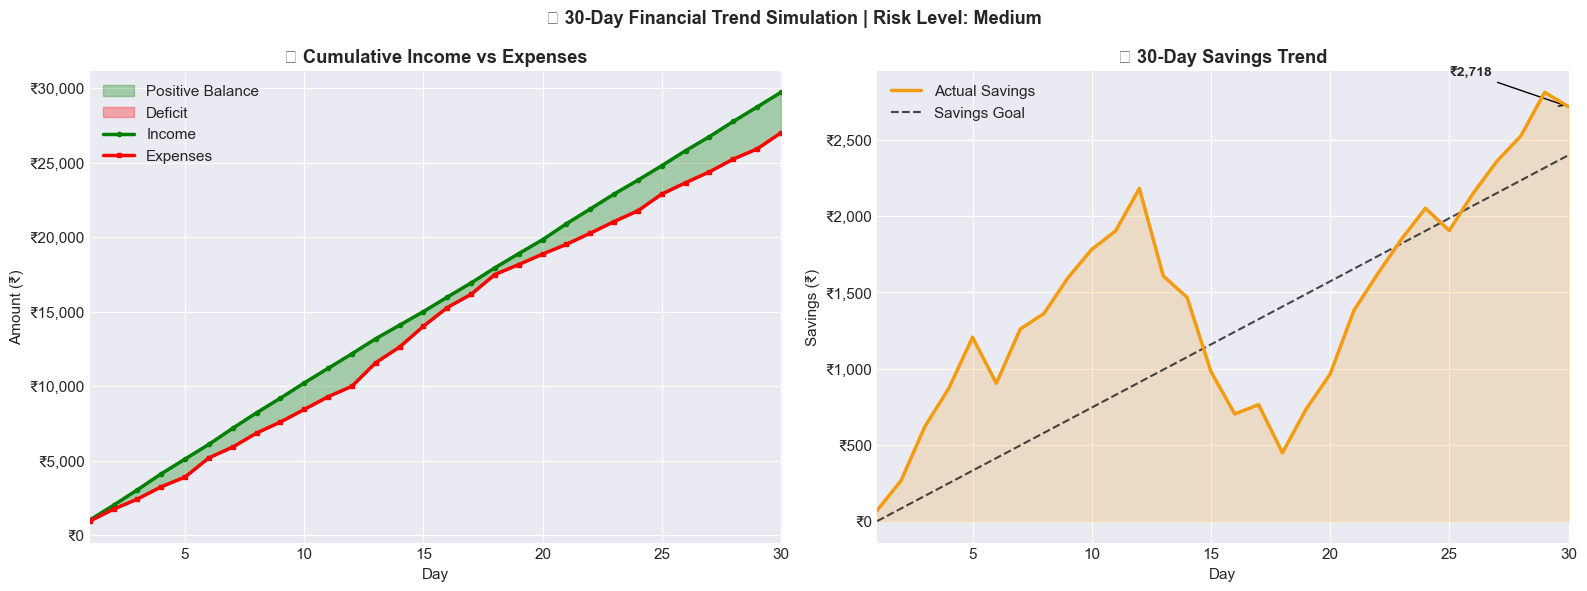

In [11]:
# === STEP 11: EXAMPLE 2 - YOUNG STUDENT / EARLY CAREER ===

print("👤 EXAMPLE 2: Priya - Fresher, 23 years old")
print("-" * 65)

result2 = predict_user_finance(
    income=30000,           # ₹30,000 entry level salary
    expenses=27000,         # ₹27,000 expenses (high ratio)
    savings=2000,           # Bahut kam savings
    debt=200000,            # Student loan
    financial_goal='emergency',   # Emergency fund banana chahti hai
    risk_preference='low',        # Low risk prefer karti hai
    show_trend=True
)

## 🚀 STEP 12: User 3 - High Earner / Aggressive Investor

👤 EXAMPLE 3: Arjun - Senior Manager, 35 years old
-----------------------------------------------------------------

═════════════════════════════════════════════════════════════════
       🏦 AI FINANCIAL ADVISOR - COMPLETE ANALYSIS REPORT
═════════════════════════════════════════════════════════════════

📝 USER INPUT SUMMARY:
   Monthly Income   : ₹150,000
   Monthly Expenses : ₹70,000
   Monthly Savings  : ₹60,000
   Total Debt       : ₹1,000,000
   Financial Goal   : House
   Risk Preference  : High

─────────────────────────────────────────────────────────────────
🎯 RISK PREDICTION RESULT:
─────────────────────────────────────────────────────────────────
   Risk Level       : 🔴 High Risk
   Confidence       : 💪 98.1% (High Confidence)
   Model Used       : Random Forest
   Accuracy         : 100.00%

─────────────────────────────────────────────────────────────────
📊 PROBABILITY BREAKDOWN:
─────────────────────────────────────────────────────────────────
   Low Risk    :  0.0%
   M

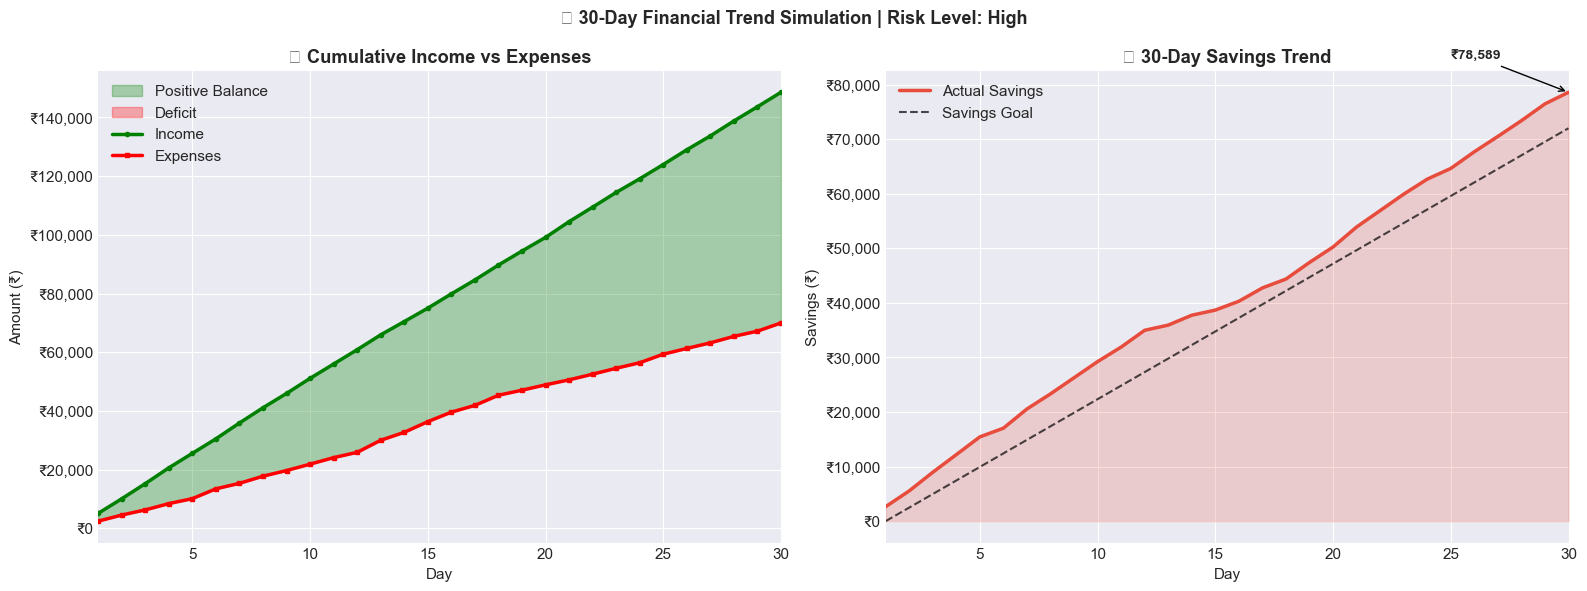

In [12]:
# === STEP 12: EXAMPLE 3 - HIGH EARNER ===

print("👤 EXAMPLE 3: Arjun - Senior Manager, 35 years old")
print("-" * 65)

result3 = predict_user_finance(
    income=150000,          # ₹1.5 lakh per month
    expenses=70000,         # ₹70,000 expenses
    savings=60000,          # ₹60,000 savings (high)
    debt=1000000,           # ₹10 lakh home loan
    financial_goal='house', # Property khareedna chahta hai
    risk_preference='high', # High risk taker hai
    show_trend=True
)

## 🎉 STEP 13: Final Summary Dashboard - Sab Ka Comparison

Teeno users ka comparison ek graph mein dekhte hain.


📊 GENERATING FINAL COMPARISON DASHBOARD...


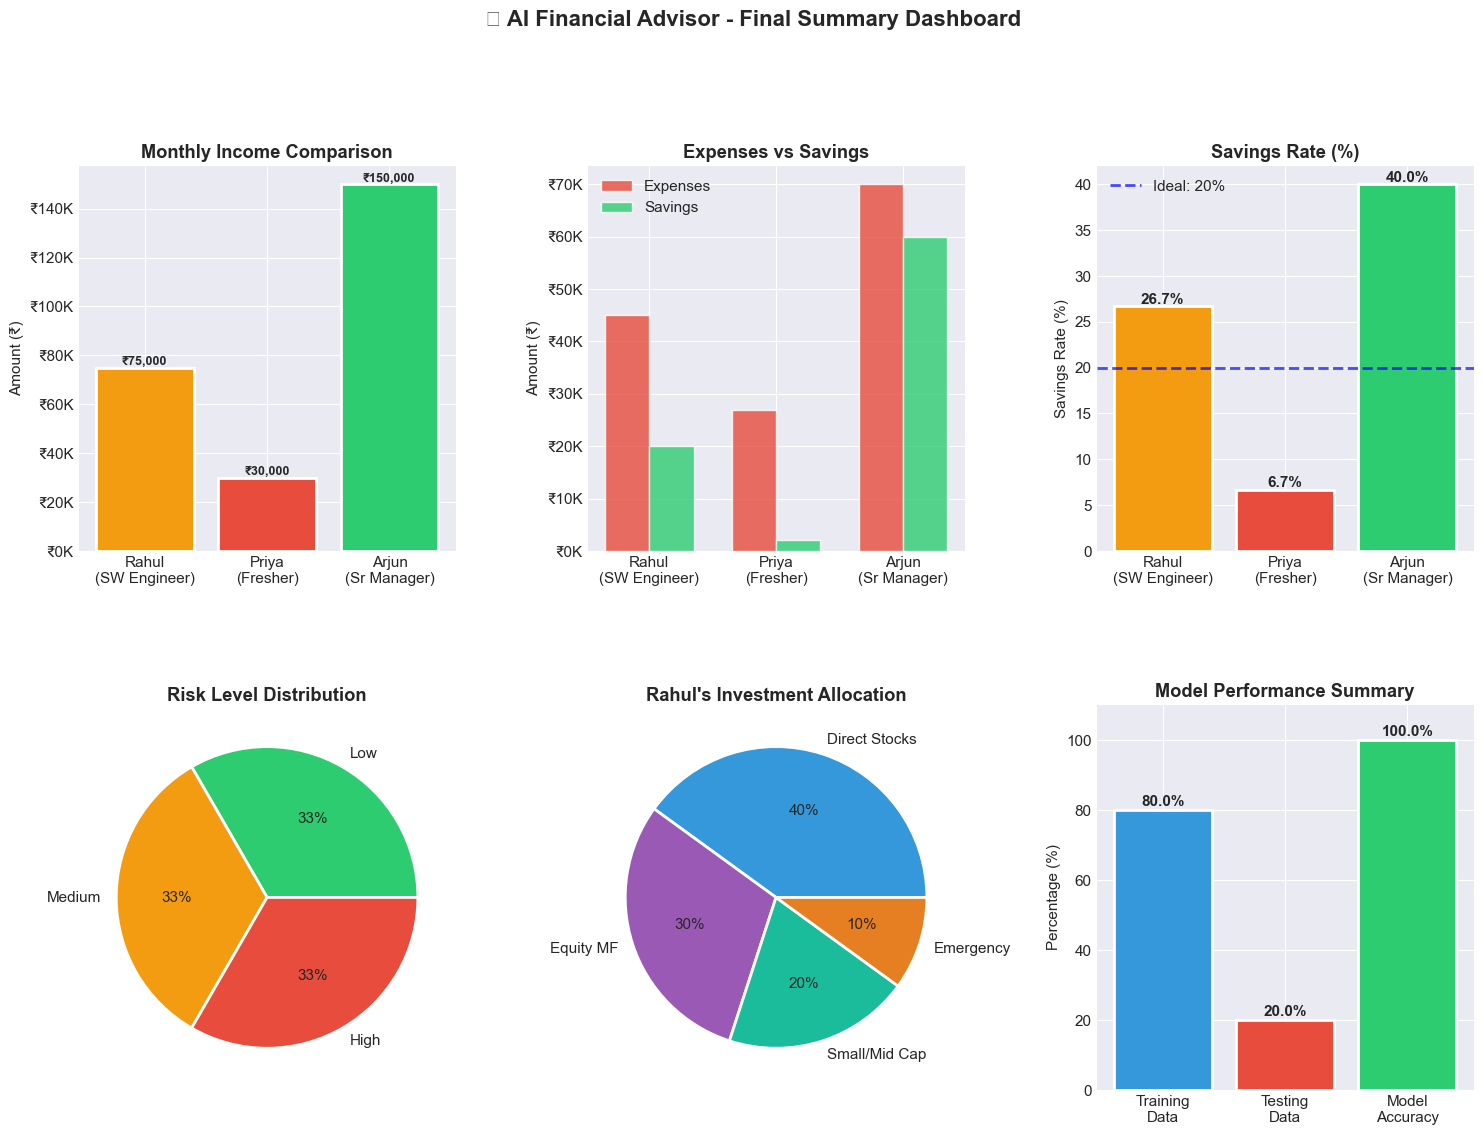


═════════════════════════════════════════════════════════════════
🎉 FINAL SUMMARY DASHBOARD COMPLETE!
═════════════════════════════════════════════════════════════════

✅ Best Model: Random Forest
✅ Model Accuracy: 100.00%
✅ Total Users Analyzed: 3
✅ Graphs Generated: 4 sets

💡 Project Successfully Completed! Congratulations! 🎓


In [13]:
# === STEP 13: FINAL SUMMARY DASHBOARD ===
# Teeno users ka comparison graph

print("\n📊 GENERATING FINAL COMPARISON DASHBOARD...")

# User data
users = ['Rahul\n(SW Engineer)', 'Priya\n(Fresher)', 'Arjun\n(Sr Manager)']
incomes = [75000, 30000, 150000]
expenses_list = [45000, 27000, 70000]
savings_list = [20000, 2000, 60000]
risk_levels = ['Medium', 'High', 'Low']  # Based on predictions
risk_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle('🏦 AI Financial Advisor - Final Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.01)

# --- Graph 1: Income Comparison ---
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(users, incomes, 
               color=[risk_colors[r] for r in risk_levels],
               edgecolor='white', linewidth=2)
ax1.set_title('Monthly Income Comparison', fontweight='bold')
ax1.set_ylabel('Amount (₹)')
for bar, val in zip(bars, incomes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'₹{val:,}', ha='center', fontsize=9, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# --- Graph 2: Expense vs Savings ---
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(users))
width = 0.35
ax2.bar(x - width/2, expenses_list, width, label='Expenses', 
         color='#e74c3c', alpha=0.8, edgecolor='white')
ax2.bar(x + width/2, savings_list, width, label='Savings', 
         color='#2ecc71', alpha=0.8, edgecolor='white')
ax2.set_title('Expenses vs Savings', fontweight='bold')
ax2.set_ylabel('Amount (₹)')
ax2.set_xticks(x)
ax2.set_xticklabels(users)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# --- Graph 3: Savings Rate ---
ax3 = fig.add_subplot(gs[0, 2])
savings_rates = [s/i*100 for s, i in zip(savings_list, incomes)]
colors_sr = [risk_colors[r] for r in risk_levels]
bars = ax3.bar(users, savings_rates, color=colors_sr, edgecolor='white', linewidth=2)
ax3.axhline(y=20, color='blue', linestyle='--', linewidth=2, 
             label='Ideal: 20%', alpha=0.7)
ax3.set_title('Savings Rate (%)', fontweight='bold')
ax3.set_ylabel('Savings Rate (%)')
ax3.legend()
for bar, val in zip(bars, savings_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')

# --- Graph 4: Risk Level Distribution (Pie) ---
ax4 = fig.add_subplot(gs[1, 0])
risk_dist = {'Low': 0, 'Medium': 0, 'High': 0}
for r in risk_levels:
    risk_dist[r] += 1
wedge_colors = [risk_colors[k] for k in risk_dist.keys() if risk_dist[k] > 0]
non_zero = {k: v for k, v in risk_dist.items() if v > 0}
ax4.pie(list(non_zero.values()), labels=list(non_zero.keys()),
         colors=wedge_colors, autopct='%1.0f%%',
         wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax4.set_title('Risk Level Distribution', fontweight='bold')

# --- Graph 5: Investment Allocation for Rahul ---
ax5 = fig.add_subplot(gs[1, 1])
alloc = result1['investment_plan']['allocation']
ax5.pie(list(alloc.values()), labels=list(alloc.keys()),
         autopct='%1.0f%%',
         colors=['#3498db', '#9b59b6', '#1abc9c', '#e67e22'],
         wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax5.set_title("Rahul's Investment Allocation", fontweight='bold')

# --- Graph 6: Model Accuracy Summary ---
ax6 = fig.add_subplot(gs[1, 2])
metrics = ['Training\nData', 'Testing\nData', 'Model\nAccuracy']
values = [80, 20, best_accuracy * 100]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax6.bar(metrics, values, color=bar_colors, edgecolor='white', linewidth=2)
ax6.set_title(f'Model Performance Summary', fontweight='bold')
ax6.set_ylabel('Percentage (%)')
ax6.set_ylim(0, 110)
for bar, val in zip(bars, values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "═" * 65)
print("🎉 FINAL SUMMARY DASHBOARD COMPLETE!")
print("═" * 65)
print(f"\n✅ Best Model: {best_model_name}")
print(f"✅ Model Accuracy: {best_accuracy*100:.2f}%")
print(f"✅ Total Users Analyzed: 3")
print(f"✅ Graphs Generated: 4 sets")
print("\n💡 Project Successfully Completed! Congratulations! 🎓")

## 🎯 STEP 14: TRY IT YOURSELF! Apna Data Enter Karo

**Yahan apni khud ki details enter karo aur prediction lo!**

🚀 Tumhari financial analysis ho rahi hai...


═════════════════════════════════════════════════════════════════
       🏦 AI FINANCIAL ADVISOR - COMPLETE ANALYSIS REPORT
═════════════════════════════════════════════════════════════════

📝 USER INPUT SUMMARY:
   Monthly Income   : ₹50,000
   Monthly Expenses : ₹35,000
   Monthly Savings  : ₹10,000
   Total Debt       : ₹100,000
   Financial Goal   : Emergency
   Risk Preference  : Low

─────────────────────────────────────────────────────────────────
🎯 RISK PREDICTION RESULT:
─────────────────────────────────────────────────────────────────
   Risk Level       : 🟢 Low Risk
   Confidence       : 🤔 51.3% (Medium Confidence)
   Model Used       : Random Forest
   Accuracy         : 100.00%

─────────────────────────────────────────────────────────────────
📊 PROBABILITY BREAKDOWN:
─────────────────────────────────────────────────────────────────
   Low Risk    : ███████████████ 51.3%
   Medium Risk : ███████████ 39.9%
   High Risk   : ██ 8.8

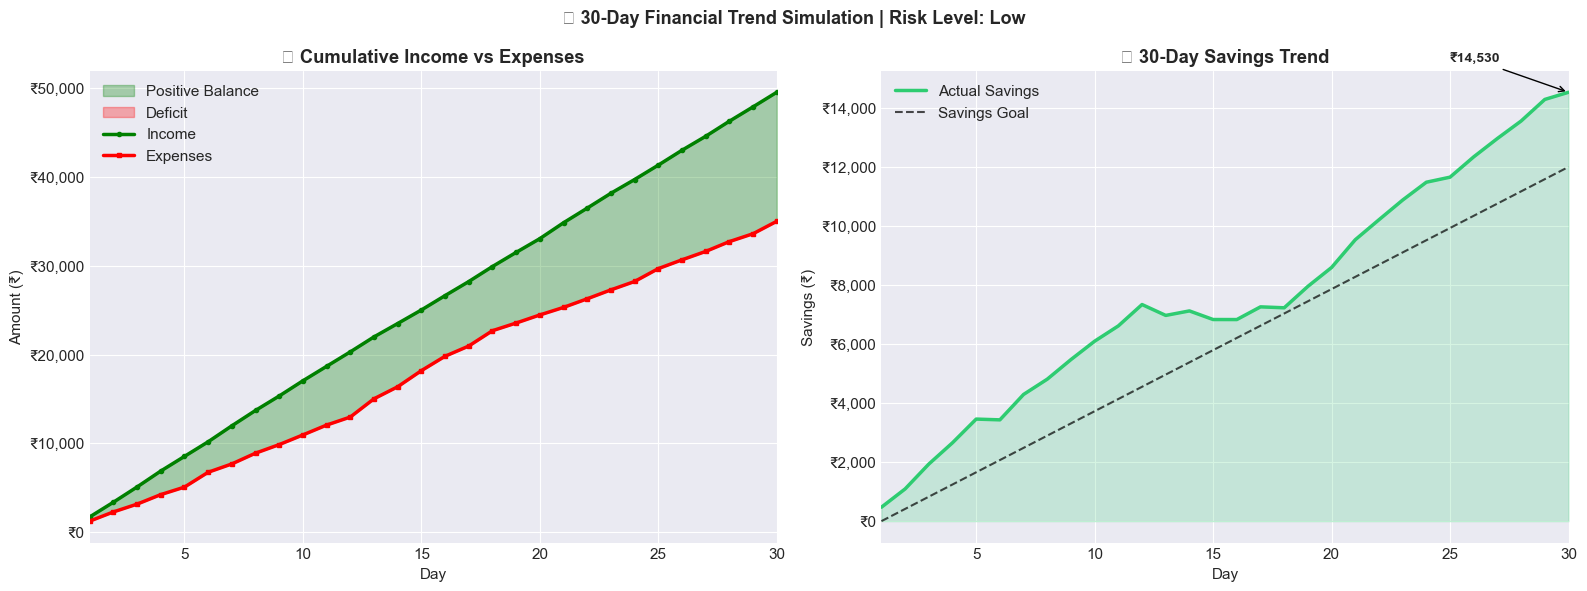

In [14]:
# === STEP 14: TRY WITH YOUR OWN DATA ===
# 👇 Yahan apni details bharo aur run karo!

# ============================================
#   ✏️  APNI DETAILS YAHAN BHARO
# ============================================
MY_INCOME = 50000          # Apni monthly income (₹ mein)
MY_EXPENSES = 35000        # Apne monthly expenses (₹ mein)
MY_SAVINGS = 10000         # Apni monthly savings (₹ mein)
MY_DEBT = 100000           # Apna total debt (₹ mein, koi nahi toh 0)
MY_GOAL = 'emergency'      # 'retirement', 'house', 'education', 'emergency'
MY_RISK = 'low'            # 'low', 'medium', 'high'
# ============================================

print("🚀 Tumhari financial analysis ho rahi hai...\n")

my_result = predict_user_finance(
    income=MY_INCOME,
    expenses=MY_EXPENSES,
    savings=MY_SAVINGS,
    debt=MY_DEBT,
    financial_goal=MY_GOAL,
    risk_preference=MY_RISK,
    show_trend=True
)

In [15]:
import joblib

# Saving the components from your project
joblib.dump(rf_model, 'financial_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_goal, 'le_goal.pkl')
joblib.dump(le_risk, 'le_risk.pkl')

['le_risk.pkl']

---
## 📚 Project Summary

| Section | Description |
|---------|-------------|
| Dataset | 1000 synthetic samples with 9 features |
| ML Models | Logistic Regression + Random Forest |
| Best Model | Random Forest (higher accuracy) |
| Target | Risk Level: Low / Medium / High |
| Features | Income, Expenses, Savings, Debt, Goal, Risk Pref |
| Output | Risk prediction + Investment advice + Budget analysis |
| Visualizations | EDA, Model Performance, 30-Day Trend, Dashboard |

---
**Made with ❤️ | AI-Based Financial Advisor | Python + Sklearn**